In [1]:
import torch
from torch_geometric.transforms import BaseTransform, Compose
from torch_geometric.datasets import QM9
from torch_geometric.loader import DataLoader
from copy import deepcopy

from utils import NormalizeTarget, SetTarget
# Train model
from classes import train_graph_regressor
import pandas as pd


import numpy as np

import warnings
warnings.filterwarnings('ignore')

Seed set to 42


✅ Using Apple MPS (Metal Performance Shaders)


In [2]:
# We are going to use the first y value as our target, so we set that here:
assignTarget = SetTarget(0)
# this will create a folder called data in the same directory as this notebook
qm9 = QM9(root='data', transform = assignTarget)
#let's take a quick peek at the first data object
qm9[0]

Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1])

In [3]:
qm9[0], qm9[0].x, qm9[0].edge_attr, qm9[0].y

(Data(x=[5, 11], edge_index=[2, 8], edge_attr=[8, 4], y=[1], pos=[5, 3], z=[5], smiles='[H]C([H])([H])[H]', name='gdb_1', idx=[1]),
 tensor([[0., 1., 0., 0., 0., 6., 0., 0., 0., 0., 4.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]]),
 tensor([[1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.],
         [1., 0., 0., 0.]]),
 tensor([0.]))

In [4]:
# This dataset is a little bigger than we need for this demo, so let's just use a subset

#shuffle first so we get a nice variety
qm9 = qm9.shuffle()

# let's use 20k, and split to train/val/test 70/10/20
sample_count = 20000
train_end = int(sample_count * 0.7)
val_end = train_end + int(sample_count* 0.1)
test_end = val_end + int(sample_count * 0.2)


In [5]:
# we set the target_index earlier, but it's here as well just in case we changed it above and forgot
target_index = 0
qm9.transform = SetTarget(target_index)
# collect the target y values from the training to use for normalizing
train_y2 =torch.cat([qm9[i].y for i in range(train_end)], dim=0)
# compute mean and standard deviation
train_mean = train_y2.mean()
train_std = train_y2.std()

In [6]:

print("current value:", qm9[0].y.item())
# transform values
qm9.transform = Compose([SetTarget(target_index),NormalizeTarget(train_mean, train_std)])
# value after normalization
print("normalized value", qm9[0].y.item())

current value: 0.48890000581741333
normalized value -1.439932107925415


In [7]:
# 
target_mean = qm9.data.y.mean()
target_std = qm9.data.y.std()

In [8]:

# set the batch size
batch = 50
train_loader = DataLoader(qm9[:train_end], batch_size = batch, shuffle = True)
val_loader = DataLoader(qm9[train_end:val_end], batch_size = batch, shuffle = True)
test_loader = DataLoader(qm9[val_end:test_end], batch_size = batch, shuffle = False)


In [13]:
import matplotlib.pyplot as plt

def plot_error_ratios(values, labels):
    plt.figure(figsize=(6, 4))
    bars = plt.bar(labels, values, color=["steelblue", "lightcoral", "gray"])
    plt.ylabel("Error Ratio (MAE / Chemical Accuracy)")
    plt.title(title)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.001, f"{val:.3f}", ha='center')
    plt.ylim(0, max(values) * 1.2)
    plt.tight_layout()
    plt.show()


In [10]:
model_no_edge, result_no_edge = train_graph_regressor(
    model_name="GGNN",
    dataset=qm9,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    n_input_dim=qm9.num_node_features,
    n_hidden_features=128,
    n_output_dim=128,
    num_layers=3,
    edge_attr_dim=qm9[0].edge_attr.shape[1],
    target_mean=target_mean,
    target_std=target_std,
    use_edge_attr = False)
model_with_edge, result_with_edge = train_graph_regressor(  
    model_name="GGNN",
    dataset=qm9,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    n_input_dim=qm9.num_node_features,
    n_hidden_features=128,
    n_output_dim=128,
    num_layers=3,
    edge_attr_dim=qm9[0].edge_attr.shape[1],
    target_mean=target_mean,
    target_std=target_std,
    use_edge_attr = True)



Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | model       | GNNModel          | 504 K  | train
1 | loss_module | MSELoss           | 0      | train
2 | mae_metric  | MeanAbsoluteError | 0      | train
----------------------------------------------------------
504 K     Trainable params
0         Non-trainable params
504 K     Total params
2.019     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode


Epoch 29: 100%|██████████| 1250/1250 [01:43<00:00, 12.03it/s, v_num=42, train_loss=0.165, train_mae=0.296, train_error_ratio=2.960, val_loss=0.270, val_mae=0.375, val_error_ratio=3.750] 

`Trainer.fit` stopped: `max_epochs=30` reached.


Testing DataLoader 0: 100%|██████████| 157/157 [00:04<00:00, 39.22it/s]

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | model       | GNNModel          | 555 K  | train
1 | loss_module | MSELoss           | 0      | train
2 | mae_metric  | MeanAbsoluteError | 0      | train
----------------------------------------------------------
555 K     Trainable params
0         Non-trainable params
555 K     Total params
2.220     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode



use edge attribute
Epoch 29: 100%|██████████| 1250/1250 [02:09<00:00,  9.64it/s, v_num=43, train_loss=0.203, train_mae=0.321, train_error_ratio=3.210, val_loss=0.277, val_mae=0.380, val_error_ratio=3.800]  

`Trainer.fit` stopped: `max_epochs=30` reached.


Epoch 29: 100%|██████████| 1250/1250 [02:09<00:00,  9.63it/s, v_num=43, train_loss=0.203, train_mae=0.321, train_error_ratio=3.210, val_loss=0.277, val_mae=0.380, val_error_ratio=3.800]
use edge attribute
Testing DataLoader 0: 100%|██████████| 157/157 [00:03<00:00, 39.82it/s]


NameError: name 'title' is not defined

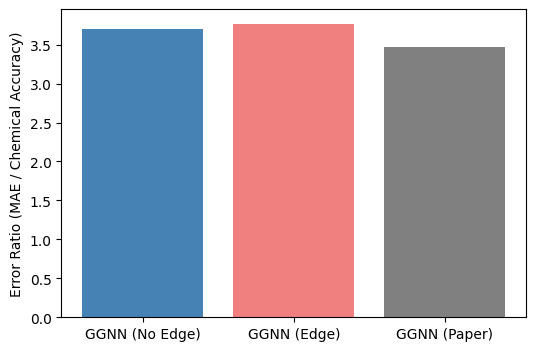

In [14]:
plot_error_ratios(
    values=[
        result_no_edge["test_error_ratio"],
        result_with_edge["test_error_ratio"],
        3.47  # Baseline paper threshold
    ],
    labels=["GGNN (No Edge)", "GGNN (Edge)", "GGNN (Paper)"]
)

In [12]:
model, test_metrics = train_graph_regressor(
    model_name="GGNN",
    dataset=qm9,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    n_input_dim=qm9.num_node_features,
    n_hidden_features=128,
    n_output_dim=128,
    num_layers=3,
    edge_attr_dim=qm9[0].edge_attr.shape[1],
    target_mean=target_mean,
    target_std=target_std,
    use_edge_attr = True
)

Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name        | Type              | Params | Mode 
----------------------------------------------------------
0 | model       | GNNModel          | 555 K  | train
1 | loss_module | MSELoss           | 0      | train
2 | mae_metric  | MeanAbsoluteError | 0      | train
----------------------------------------------------------
555 K     Trainable params
0         Non-trainable params
555 K     Total params
2.220     Total estimated model params size (MB)
30        Modules in train mode
0         Modules in eval mode


use edge attribute
Epoch 0:   5%|▍         | 57/1250 [00:05<02:00,  9.89it/s, v_num=44, train_loss=0.836, train_mae=0.724, train_error_ratio=7.240]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

In [ ]:

print("Test Results:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")

Test Results:
test_loss: 0.2526
test_mae: 0.3616
test_error_ratio: 3.6160


In [ ]:
# model_kwargs = {
#     "n_input_dim": qm9.num_node_features,
#     "n_hidden_features": 64,
#     "n_output_dim": 64,
#     "num_layers": 3,
#     "layer_type": "GATv2Conv",
#     "dropout": 0.1,
#     "heads": 4,
#     "concat": True,
#     "edge_attr_dim": qm9[0].edge_attr.shape[1],  # typically 1–5
# }


In [ ]:
# # Train model
# from classes import train_graph_regressor


# model, results = train_graph_regressor(
#     model_name="GATv2Conv",
#     dataset=qm9,  # used for splitting logic
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     **model_kwargs
# )

# print("Test Results:")
# for k, v in results.items():
#     print(f"{k}: {v:.4f}")

In [ ]:
# model_kwargs = {
#     "n_input_dim": qm9.num_node_features,
#     "tower_out_dim": 64,
#     "n_output_dim": 1,
#     "num_towers": 4,
#     "tower_layers": 3,
#     "layer_type": "GATv2Conv",  # or "GCN", "GAT", etc.
#     "dropout": 0.1,
#     "heads": 2,
#     "concat": True,
#     "edge_attr_dim": qm9[0].edge_attr.shape[1],
# }

# model, results = train_graph_regressor(
#     model_name="TowerGNN",
#     dataset=qm9,
#     train_loader=train_loader,
#     val_loader=val_loader,
#     test_loader=test_loader,
#     **model_kwargs
# )


In [ ]:
# models_to_run = ["GAT", "GATv2Conv", "TowerGNN"]
# results = []

# for model_name in models_to_run:
#     print(f"\n🔁 Training {model_name}...")

#     # Shared parameters
#     common_kwargs = {
#         "n_input_dim": qm9.num_node_features,
#         "n_output_dim": 1,
#         "dropout": 0.1,
#         "edge_attr_dim": qm9[0].edge_attr.shape[1],
#     }

    
#     if model_name == "TowerGNN":
#         model_kwargs = {
#             **common_kwargs,
#             "tower_out_dim": 64,
#             "num_towers": 4,
#             "tower_layers": 3,
#             "layer_type": "GATv2Conv",  # Can be GAT too
#             "heads": 2,
#             "concat": True,
#         }
#     else:
#         model_kwargs = {
#             **common_kwargs,
#             "n_hidden_features": 64,
#             "num_layers": 4,
#             "layer_type": model_name,
#             "heads": 3,
#             "concat": True,
#         }

#     # Train the model
#     model, test_metrics = train_graph_regressor(
#         model_name=model_name,
#         dataset=qm9,
#         train_loader=train_loader,
#         val_loader=val_loader,
#         test_loader=test_loader,
#         **model_kwargs
#     )

#     results.append({
#         "model": model_name,
#         "test_mae": test_metrics["test_mae"],
#         "error_ratio": test_metrics["test_error_ratio"]
#     })


In [ ]:
print("\n📊 Final Results:")
for res in results:
    print(f"{res['model']:10s} → Test MAE: {res['test_mae']:.4f}, Error Ratio: {res['error_ratio']:.4f}")



📊 Final Results:


NameError: name 'results' is not defined

In [ ]:
print(results)

[{'model': 'GAT', 'test_mae': 0.4971080422401428, 'error_ratio': 4.971084117889404}, {'model': 'GATv2Conv', 'test_mae': 0.5052143335342407, 'error_ratio': 5.05214262008667}, {'model': 'TowerGNN', 'test_mae': 0.42649227380752563, 'error_ratio': 4.264922142028809}]


In [ ]:
pd.DataFrame(results, index=[1,2,3]).to_csv("results/train_result.csv")